# agentv11_human_in_loop — Explicit Human Approval

This version introduces explicit approve/reject input.

Graph:

```text
START → planner → approval_gate → execute_action → final_answer → END
```

The graph pauses before `approval_gate`.

Then the human decision is written into checkpointed state using:

```python
graph.update_state(config, {"approval_decision": "approved"})
```

or:

```python
graph.update_state(config, {"approval_decision": "rejected"})
```


## 1. Install dependencies

```bash
pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter
```


In [1]:
# Optional: uncomment in a fresh environment.
# %pip install -U langgraph langchain langchain-openai langsmith python-dotenv ipython jupyter


## 2. Load environment variables


In [2]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define state


In [3]:
from typing import Literal, TypedDict

ApprovalDecision = Literal["approved", "rejected"]

class AgentState(TypedDict, total=False):
    input: str
    proposed_action: str
    approval_decision: ApprovalDecision
    execution_result: str
    final_answer: str


## 4. Normalize human decision


In [4]:
def normalize_decision(raw: str) -> ApprovalDecision:
    value = raw.strip().lower()
    if value in {"approve", "approved", "yes", "y"}:
        return "approved"
    return "rejected"


## 5. Planner node

The planner prepares an action. It does not execute it.


In [5]:
def planner_node(state: AgentState) -> AgentState:
    user_request = state["input"]

    proposed_action = (
        "Proposed action: restart the EPP health-check worker service "
        "and collect post-restart error metrics for 10 minutes. "
        f"Original request: {user_request}"
    )

    return {"proposed_action": proposed_action}


## 6. Approval gate node

This node validates the decision from human input.

If approval is missing, it rejects by default.


In [6]:
def approval_gate_node(state: AgentState) -> AgentState:
    decision = state.get("approval_decision")

    if decision not in {"approved", "rejected"}:
        return {"approval_decision": "rejected"}

    return {"approval_decision": decision}


## 7. Execute action node


In [7]:
def execute_action_node(state: AgentState) -> AgentState:
    if state.get("approval_decision") != "approved":
        return {"execution_result": "Action skipped because approval was rejected or missing."}

    return {
        "execution_result": (
            "Executed approved action: restarted EPP health-check worker service. "
            "Post-action metrics collection started."
        )
    }


## 8. Final answer node


In [8]:
def final_answer_node(state: AgentState) -> AgentState:
    return {
        "final_answer": (
            f"{state['proposed_action']}\n\n"
            f"Approval decision: {state.get('approval_decision')}\n"
            f"Execution result: {state.get('execution_result')}"
        )
    }


## 9. Build graph with interrupt

`interrupt_before=["approval_gate"]` pauses the graph before approval.


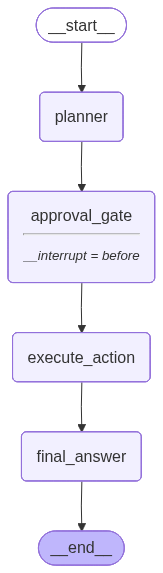

In [9]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import START, END, StateGraph

checkpointer = InMemorySaver()

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("planner", planner_node)
    graph_builder.add_node("approval_gate", approval_gate_node)
    graph_builder.add_node("execute_action", execute_action_node)
    graph_builder.add_node("final_answer", final_answer_node)

    graph_builder.add_edge(START, "planner")
    graph_builder.add_edge("planner", "approval_gate")
    graph_builder.add_edge("approval_gate", "execute_action")
    graph_builder.add_edge("execute_action", "final_answer")
    graph_builder.add_edge("final_answer", END)

    return graph_builder.compile(
        checkpointer=checkpointer,
        interrupt_before=["approval_gate"],
    )

graph = build_graph()
graph


## 10. Visualize Mermaid graph


In [10]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	approval_gate(approval_gate<hr/><small><em>__interrupt = before</em></small>)
	execute_action(execute_action)
	final_answer(final_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	approval_gate --> execute_action;
	execute_action --> final_answer;
	planner --> approval_gate;
	final_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



## 11. Visualize PNG graph


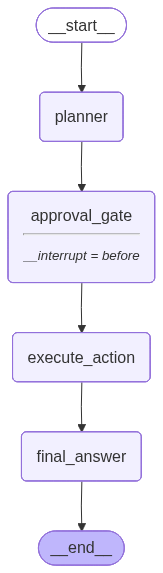

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("PNG rendering failed.")
    print("Reason:", e)


## 12. First invoke: graph pauses before approval

`thread_id` is required because the interrupted state must be saved.


In [12]:
config = {"configurable": {"thread_id": "human-loop-demo"}}

first_result = graph.invoke(
    {"input": "Fix EPP health-check failures after latest release."},
    config=config,
)

first_result


{'input': 'Fix EPP health-check failures after latest release.',
 'proposed_action': 'Proposed action: restart the EPP health-check worker service and collect post-restart error metrics for 10 minutes. Original request: Fix EPP health-check failures after latest release.'}

## 13. Inspect paused state

At this point, the graph has not executed the action.


In [13]:
paused_state = graph.get_state(config)

print("Next node(s):", paused_state.next)
print()
print("Proposed action:")
print(paused_state.values.get("proposed_action"))
print()
print("Execution result:", paused_state.values.get("execution_result"))


Next node(s): ('approval_gate',)

Proposed action:
Proposed action: restart the EPP health-check worker service and collect post-restart error metrics for 10 minutes. Original request: Fix EPP health-check failures after latest release.

Execution result: None


## 14. Human approval input

In a notebook, `input()` will prompt you interactively.

Type:

```text
approve
```

or:

```text
reject
```


In [14]:
raw_decision = input("Approve action? Type approve or reject: ")
approval_decision = normalize_decision(raw_decision)

approval_decision


'approved'

## 15. Write human decision into graph state

This is the key step.

The decision is saved into the checkpointed state before resume.


In [15]:
graph.update_state(
    config,
    {"approval_decision": approval_decision},
)

updated_state = graph.get_state(config)

print("Approval decision in state:", updated_state.values.get("approval_decision"))
print("Next node(s):", updated_state.next)


Approval decision in state: approved
Next node(s): ('approval_gate',)


## 16. Resume graph

Now the graph resumes from the paused node.

`approval_gate` reads the human decision.

`execute_action` executes only if the decision is `approved`.


In [16]:
resumed_result = graph.invoke(None, config=config)

print(resumed_result["final_answer"])


Proposed action: restart the EPP health-check worker service and collect post-restart error metrics for 10 minutes. Original request: Fix EPP health-check failures after latest release.

Approval decision: approved
Execution result: Executed approved action: restarted EPP health-check worker service. Post-action metrics collection started.


## 17. Test reject path with a new thread

This shows that rejection skips execution.


In [17]:
reject_config = {"configurable": {"thread_id": "human-loop-reject-demo"}}

graph.invoke(
    {"input": "Restart production worker service."},
    config=reject_config,
)

reject_paused_state = graph.get_state(reject_config)
print("Proposed action:", reject_paused_state.values.get("proposed_action"))

graph.update_state(
    reject_config,
    {"approval_decision": "rejected"},
)

reject_result = graph.invoke(None, config=reject_config)
print()
print(reject_result["final_answer"])


Proposed action: Proposed action: restart the EPP health-check worker service and collect post-restart error metrics for 10 minutes. Original request: Restart production worker service.

Proposed action: restart the EPP health-check worker service and collect post-restart error metrics for 10 minutes. Original request: Restart production worker service.

Approval decision: rejected
Execution result: Action skipped because approval was rejected or missing.


## 18. Why this matters

This is the correct safety pattern:

```text
propose → interrupt → approve/reject → resume → execute or skip
```

Use this for any real action that can affect systems, data, cost, or users.


## 19. LangSmith trace

Open project:

```text
langgraph-playground
```

You should see:
- first run paused before approval
- state update with approval decision
- resumed execution
- action executed or skipped
